In [1]:
#complete data condition: AC vs GridFM vs LLM-OPF (ATT1) Time Comparison(0–3s view)

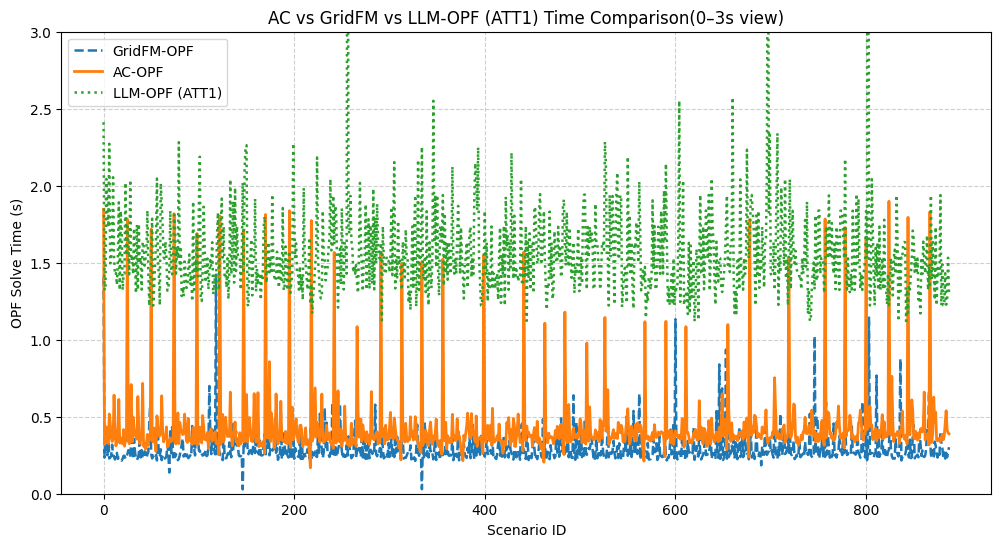

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


ac_path    = "/Users/hhujunqi/Desktop/HHOPF/DATAKITEND/case24/case24_ieee_rts/raw/opf_times.csv"
gridfm_path = "/Users/hhujunqi/Desktop/HHOPF/GRIDFMOPF_FINAL/case24/opf_time.csv"
llm_path    = "/Users/hhujunqi/Desktop/HHOPF/GPTOPF_FINAL/case24/opf_time.csv"  


def load_with_time(path, name):
    df = pd.read_csv(path)
    df.columns = [c.lower().strip() for c in df.columns]
    time_candidates = [c for c in df.columns if "time" in c or "sec" in c]
    if not time_candidates:
        raise ValueError(f"{name} 没找到时间列: {df.columns}")
    time_col = time_candidates[0]
    df = df.rename(columns={time_col: f"{name}_time"})
    return df

ac    = load_with_time(ac_path, "ac_opf")
gridfm = load_with_time(gridfm_path, "gridfm_opf")


llm = pd.read_csv(llm_path)
llm.columns = [c.lower().strip() for c in llm.columns]
if "time_att1" not in llm.columns:
    raise ValueError(f"llmopf_cost.csv 里没找到 time_att1 列: {llm.columns}")
llm = llm.rename(columns={"time_att1": "llmopf_time"})


min_len = min(len(ac), len(gridfm), len(llm))
ac    = ac.iloc[:min_len]
gridfm = gridfm.iloc[:min_len]
llm    = llm.iloc[:min_len]


merged = pd.DataFrame({
    "scenario": range(min_len),
    "AC-OPF": ac["ac_opf_time"],
    "GridFM-OPF": gridfm["gridfm_opf_time"],
    "LLM-OPF_ATT1": llm["llmopf_time"],
})


plt.figure(figsize=(12,6))
plt.plot(merged["scenario"], merged["GridFM-OPF"],   label="GridFM-OPF",   linestyle="--", linewidth=1.8)
plt.plot(merged["scenario"], merged["AC-OPF"],  label="AC-OPF",  linewidth=2)
plt.plot(merged["scenario"], merged["LLM-OPF_ATT1"], label="LLM-OPF (ATT1)", linestyle=":", linewidth=1.8)

plt.xlabel("Scenario ID")
plt.ylabel("OPF Solve Time (s)")
plt.title("AC vs GridFM vs LLM-OPF (ATT1) Time Comparison(0–3s view)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim(0, 3)
plt.tight_layout

plt.savefig(
    "/Users/hhujunqi/Desktop/HHOPF/AC_GRIDFM_LLM_time_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


In [ ]:
#complete data condition: Total Cost(EUR) Comparison of AC OPF, GridFM-OPF, and LLM-OPF (ATT3)

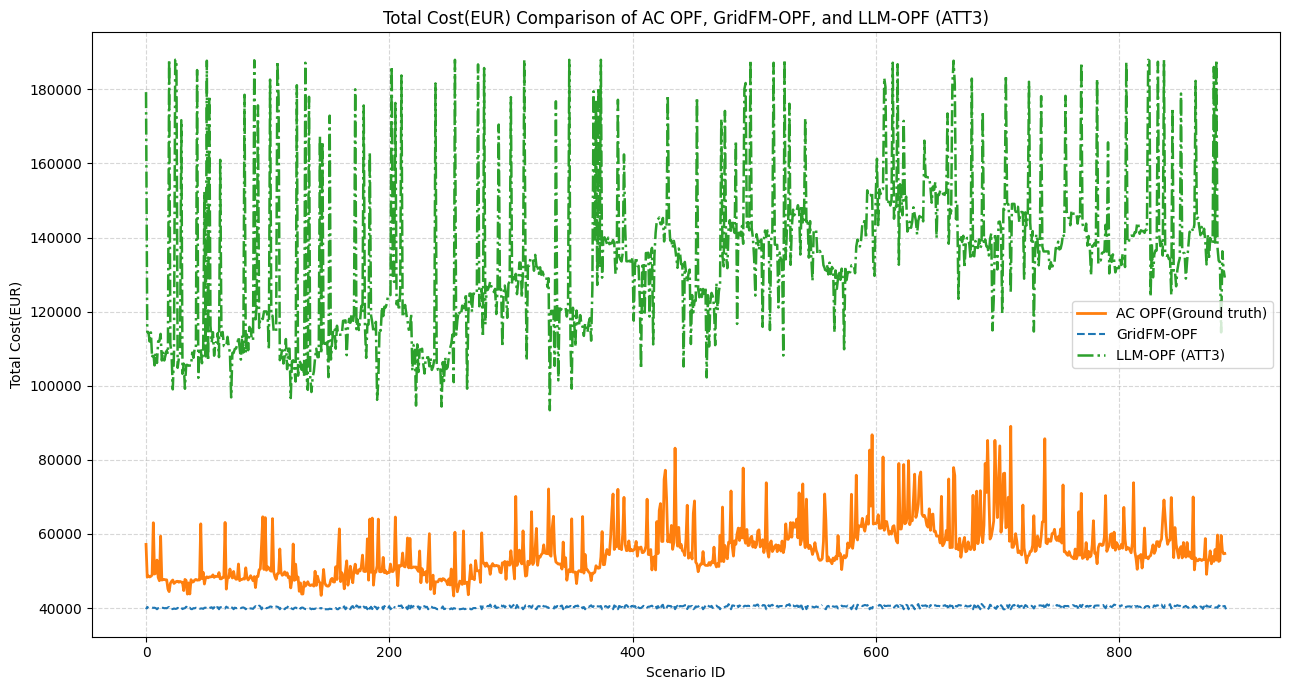

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


ac_path    = "/Users/hhujunqi/Desktop/HHOPF/DATAKITEND/case24/case24_ieee_rts/raw/opf_cost.csv"
gridfm_path = "/Users/hhujunqi/Desktop/HHOPF/GRIDFMOPF_FINAL/case24/opf_cost.csv"
llm_path    = "/Users/hhujunqi/Desktop/HHOPF/GPTOPF_FINAL/case24/opf_cost.csv"


ac     = pd.read_csv(ac_path).sort_values("scenario").reset_index(drop=True)
gridfm  = pd.read_csv(gridfm_path).sort_values("scenario").reset_index(drop=True)
llm     = pd.read_csv(llm_path).sort_values("scenario").reset_index(drop=True)


if "cost_att1" not in llm.columns or "cost_att3" not in llm.columns:
    raise ValueError("gptopf_cost.csv 里缺少 cost_att1 或 cost_att3")


min_len = min(len(ac), len(gridfm), len(llm))
ac     = ac.iloc[:min_len]
gridfm  = gridfm.iloc[:min_len]
llm     = llm.iloc[:min_len]


plt.figure(figsize=(13,7))

plt.plot(ac["scenario"], ac["total_cost"],
         label="AC OPF(Ground truth)",
         color="#ff7f0e", linewidth=2)

plt.plot(gridfm["scenario"], gridfm["total_cost"],
         label="GridFM-OPF",
         color="#1f77b4", linestyle="--", linewidth=1.5)


plt.plot(llm["scenario"], llm["cost_att3"],
         label="LLM-OPF (ATT3)",
         color="#2ca02c", linestyle="-.", linewidth=1.8)

plt.xlabel("Scenario ID")
plt.ylabel("Total Cost(EUR)")
plt.title("Total Cost(EUR) Comparison of AC OPF, GridFM-OPF, and LLM-OPF (ATT3)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig(
    "/Users/hhujunqi/Desktop/HHOPF/AC_GRIDFM_LLM_totalcost_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
#LLM_iteration_strategy: GPT-OPF (ATT1) vs GPT-OPF (ATT3) Time Comparison

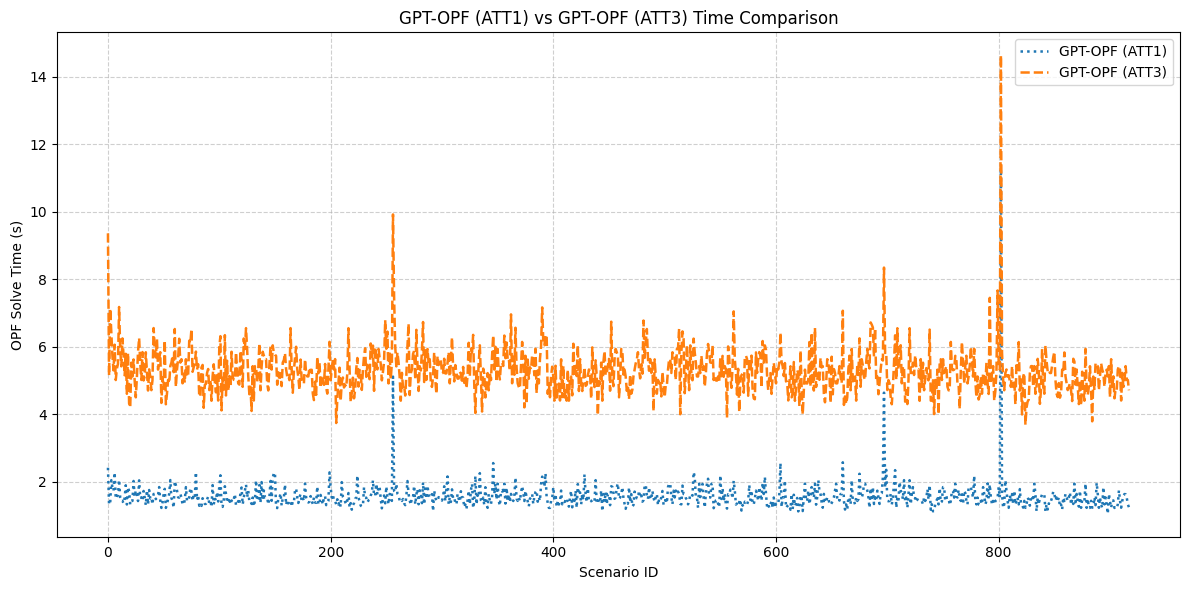

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


gpt_path = "/Users/hhujunqi/Desktop/HHOPF/GPTOPF_FINAL/case24/opf_time.csv"


gpt = pd.read_csv(gpt_path)
gpt.columns = [c.lower().strip() for c in gpt.columns]


if "time_att1" not in gpt.columns or "time_att3" not in gpt.columns:
    raise ValueError(f"缺少 time_att1 或 time_att3 列: {gpt.columns}")


plt.figure(figsize=(12,6))

plt.plot(gpt.index, gpt["time_att1"], label="GPT-OPF (ATT1)", linestyle=":", linewidth=1.8)
plt.plot(gpt.index, gpt["time_att3"], label="GPT-OPF (ATT3)", linestyle="--", linewidth=1.8)

plt.xlabel("Scenario ID")
plt.ylabel("OPF Solve Time (s)")
plt.title("GPT-OPF (ATT1) vs GPT-OPF (ATT3) Time Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig(
    "/Users/hhujunqi/Desktop/HHOPF/LLM(ATT1vsATT3)_time_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()


In [ ]:
#LLM_iteration_strategy:Total Cost(EUR) Comparison of LLM-OPF (ATT1, ATT3) vs. AC-OPF Ground Truth

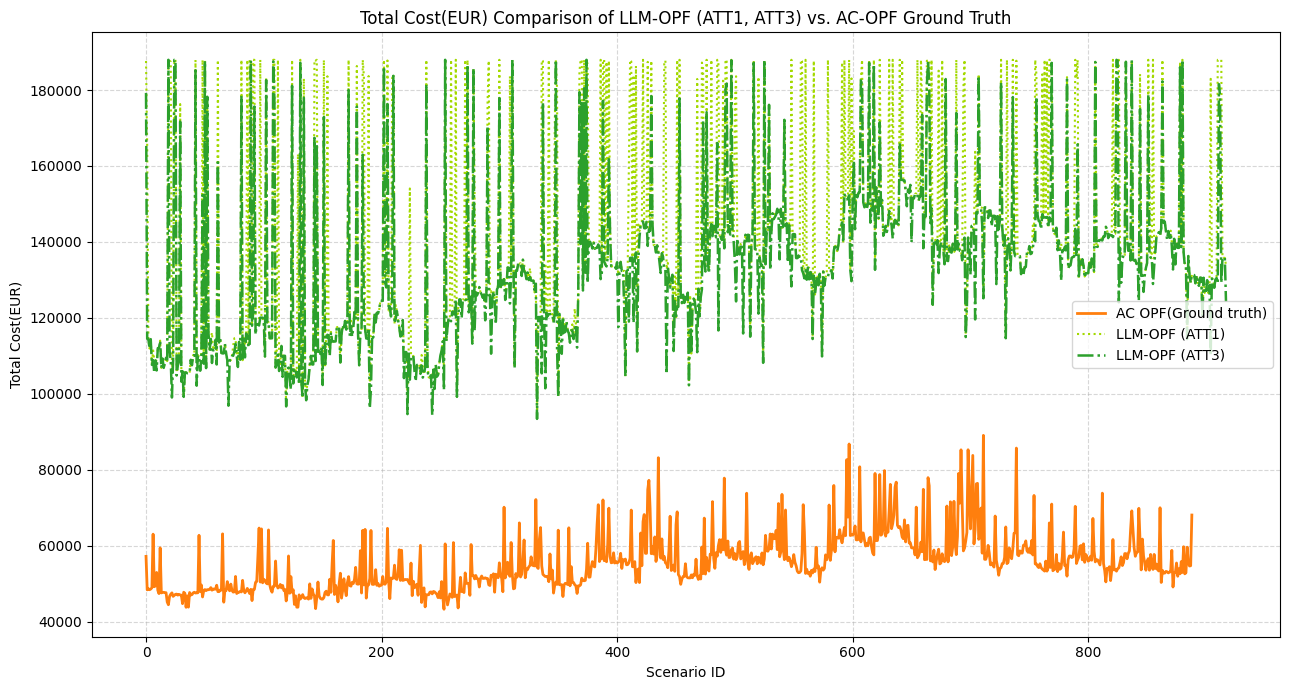

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


ac_path    = "/Users/hhujunqi/Desktop/HHOPF/DATAKITEND/case24/case24_ieee_rts/raw/opf_cost.csv"
llm_path    = "/Users/hhujunqi/Desktop/HHOPF/GPTOPF_FINAL/case24/opf_cost.csv"


ac     = pd.read_csv(ac_path).sort_values("scenario").reset_index(drop=True)
llm     = pd.read_csv(llm_path).sort_values("scenario").reset_index(drop=True)


if "cost_att1" not in llm.columns or "cost_att3" not in llm.columns:
    raise ValueError("llmopf_cost.csv 里缺少 cost_att1 或 cost_att3")



plt.figure(figsize=(13,7))

plt.plot(ac["scenario"], ac["total_cost"],
         label="AC OPF(Ground truth)",
         color="#ff7f0e", linewidth=2)

plt.plot(llm["scenario"], llm["cost_att1"],
         label="LLM-OPF (ATT1)",
         color="#A3D900", linestyle=":", linewidth=1.5)

plt.plot(llm["scenario"], llm["cost_att3"],
         label="LLM-OPF (ATT3)",
         color="#2ca02c", linestyle="-.", linewidth=1.8)

plt.xlabel("Scenario ID")
plt.ylabel("Total Cost(EUR)")
plt.title("Total Cost(EUR) Comparison of LLM-OPF (ATT1, ATT3) vs. AC-OPF Ground Truth")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig(
    "/Users/hhujunqi/Desktop/HHOPF/LLM(ATT1vsATT3)_totalcost_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
#missing data condition: Total Cost(EUR) Comparison of GridFM-OPF and GridFM_Missing-OPF

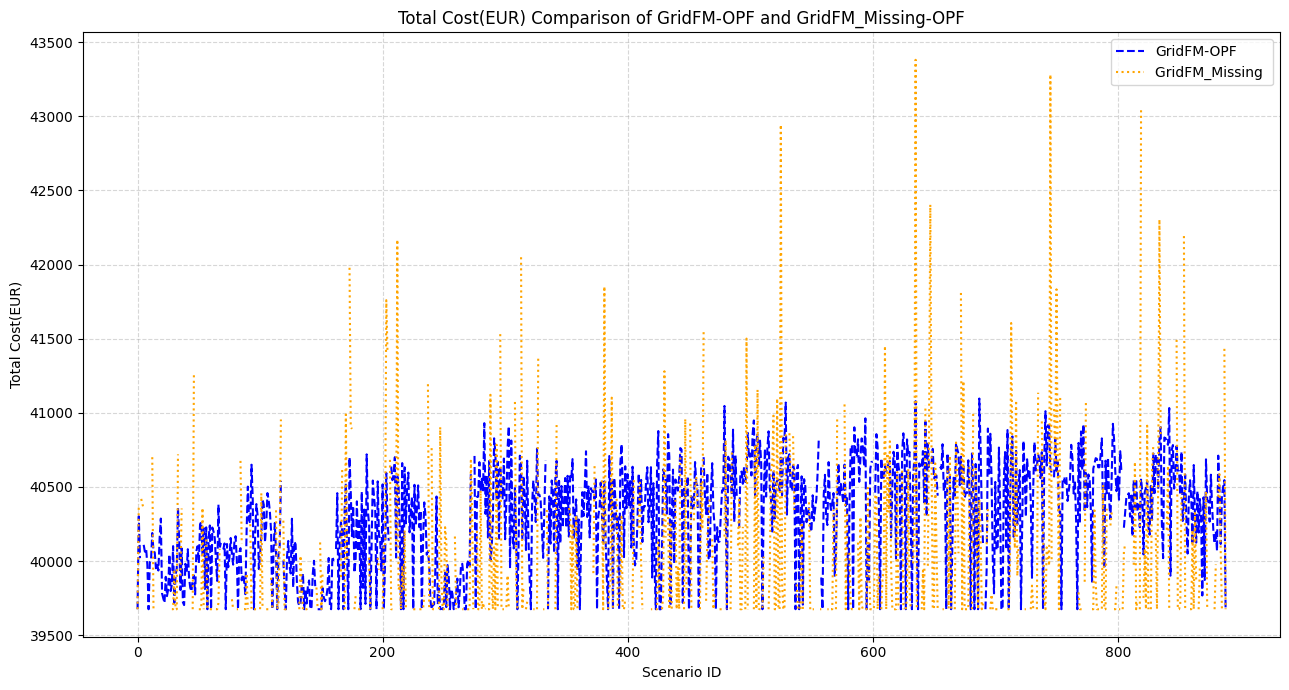

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



gridfm_path = "/Users/hhujunqi/Desktop/HHOPF/GRIDFMOPF_FINAL/case24/opf_cost.csv"
gridfm_missing_path = "/Users/hhujunqi/Desktop/HHOPF/GRIDFM_FINAL_missing/case24/opf_cost.csv"


gridfm = pd.read_csv(gridfm_path).sort_values("scenario").reset_index(drop=True)
gridfm_missing = pd.read_csv(gridfm_missing_path).sort_values("scenario").reset_index(drop=True)



min_len = min(len(gridfm), len(gridfm_missing))
gridfm = gridfm.iloc[:min_len]
gridfm_missing = gridfm_missing.iloc[:min_len]


plt.figure(figsize=(13,7))

plt.plot(gridfm["scenario"], gridfm["total_cost"],
         label="GridFM-OPF",
         color="blue", linestyle="--", linewidth=1.5)

plt.plot(gridfm_missing ["scenario"], gridfm_missing["total_cost"],
         label="GridFM_Missing ",
         color="orange", linestyle=":", linewidth=1.5)

plt.xlabel("Scenario ID")
plt.ylabel("Total Cost(EUR)")
plt.title("Total Cost(EUR) Comparison of GridFM-OPF and GridFM_Missing-OPF")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig(
    "/Users/hhujunqi/Desktop/HHOPF/GridFM_Complete_Missing-OPF_Comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


plt.show()
